# 第 5 章 · 图搜索算法

在同一校园图上，逐步观察 BFS、DFS、UCS、Greedy、A* 的**队列 / 栈 / 优先队列**如何驱动搜索，并对照 [ch5.html](../ch5.html) 动画。

配套交互演示：[章节网页](../ch5.html)

## 本节目标

- 用邻接表表示无向加权图
- 用队列、栈、优先队列看懂每一步 frontier 变化
- 对比 BFS/DFS/UCS/Greedy/A* 的取出规则与路径结果

## 1. 图与搜索问题

**顶点**表示地点（`x` 校门口、`s1` 食堂、`c1` 操场）。**边**附带步行分钟数（权重）。

**搜索**：从起点到目标找路径；算法差异在于「下一步探索哪个节点」。

**形式化**

```text
START=x, GOAL=c1
PATH = 相邻顶点序列
COST = 路径上边权之和
```

**思考** · 无向边 x↔s1 在邻接表中如何存储？

<details class="ai-self-check"><summary>查看答案</summary><p>两端各存一条，便于双向扩展。</p></details>

## 2. 加载校园图

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd()
if not (ROOT / "labs").exists() and (ROOT.parent / "labs").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "labs"))
sys.path.insert(0, str(ROOT / "labs" / "ch05"))
import matplotlib.pyplot as plt
from common.mpl_setup import configure_matplotlib
configure_matplotlib()
from IPython.display import display, Image
from search_algorithms import *
from common.codelens import frames_to_table

In [2]:
graph = load_graph()

In [3]:
print('起点', graph['start'], '-> 目标', graph['goal'])

起点 x -> 目标 c1


In [4]:
display(graph_summary())

,节点,名称,h(到操场)
6,c1,操场,0
1,c2,超市,1
2,j,教学楼,4
4,s1,食堂,3
3,s2,实验楼,4
5,t,图书馆,2
0,x,校门口,7


In [5]:
display(edges_table())

,边,代价
0,x↔c2,7
1,x↔j,2
2,x↔s1,2
3,j↔s2,4
4,s2↔s1,1
5,s1↔t,3
6,s1↔c1,6
7,t↔c1,2


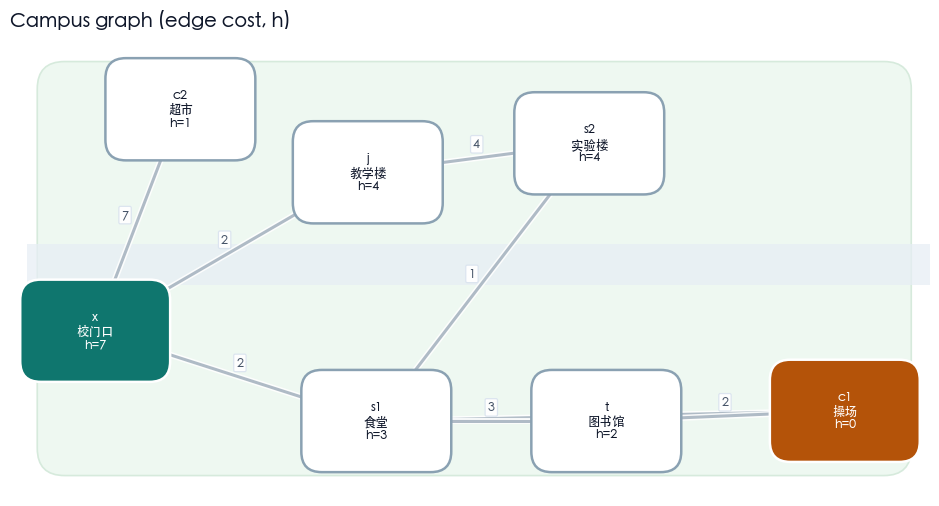

In [6]:
plot_campus(title='Campus graph (edge cost, h)')

In [7]:
display(neighbors_table('x'))

,邻居,边代价,h
0,c2,7,1
1,j,2,4
2,s1,2,3


### 2.1 先看 frontier 容器

图搜索的核心不是“记住路线”，而是每一步从 frontier 里取谁。

In [8]:
display(container_cheatsheet())

,算法,frontier 类型,取出动作,加入动作,下一步选择规则
0,BFS,Queue / 队列,frontier.popleft(),append(right),保持入队顺序，左端先出
1,DFS,Stack / 栈,stack.pop(),append(top),后进先出，栈顶先出
2,UCS,Priority queue / 优先队列,pop_min(g),push by g,按累计代价 g 从小到大取出
3,Greedy,Priority queue / 优先队列,pop_min(h),push by h,按启发式 h 从小到大取出
4,A*,Priority queue / 优先队列,pop_min(f),push by f=g+h,按 f=g+h 从小到大取出


## 3. 构建邻接表（逐步）

**核心循环**

```text
for edge in edges:
    adj[a].append((b,cost)); adj[b].append((a,cost))
```

In [9]:
frames_adj = codelens_build_adjacency()

In [10]:
display(frames_to_table(frames_adj, ['边', '代价']))

,步,说明,边,代价
0,0,初始化空邻接表,,
1,1,第 1 条边写入邻接表,x↔c2,7
2,2,第 2 条边写入邻接表,x↔j,2
3,3,第 3 条边写入邻接表,x↔s1,2
4,4,第 4 条边写入邻接表,j↔s2,4
5,5,第 5 条边写入邻接表,s2↔s1,1
6,6,第 6 条边写入邻接表,s1↔t,3
7,7,第 7 条边写入邻接表,s1↔c1,6
8,8,第 8 条边写入邻接表,t↔c1,2


In [11]:
adj = build_adjacency(graph['edges'])

In [12]:
print('adj[x] =', adj['x'])

adj[x] = [('c2', 7), ('j', 2), ('s1', 2)]


## 4. 广度优先 BFS

### 4.1 队列与层序

FIFO 队列：队头出、队尾进。等权图上保证**最少步数**。

**BFS**

```text
from collections import deque
frontier = deque(['x'])
u = frontier.popleft()
frontier.append(v)
```

In [13]:
display(operation_trace('bfs'))

,步,算法,取出动作,取出节点,frontier 取出前,frontier 取出后,新加入 / 更新,下一轮 frontier,visited,到达?
0,1,BFS,frontier.popleft(),x,x,∅,push c2；push j；push s1,c2 | j | s1,x,False
1,2,BFS,frontier.popleft(),c2,c2 | j | s1,j | s1,—,j | s1,x→c2,False
2,3,BFS,frontier.popleft(),j,j | s1,s1,push s2,s1 | s2,x→c2→j,False
3,4,BFS,frontier.popleft(),s1,s1 | s2,s2,push c1；push t,s2 | c1 | t,x→c2→j→s1,False
4,5,BFS,frontier.popleft(),s2,s2 | c1 | t,c1 | t,—,c1 | t,x→c2→j→s1→s2,False
5,6,BFS,frontier.popleft(),c1,c1 | t,t,—,t,x→c2→j→s1→s2→c1,True


BFS: Queue / 队列 frontier 动画



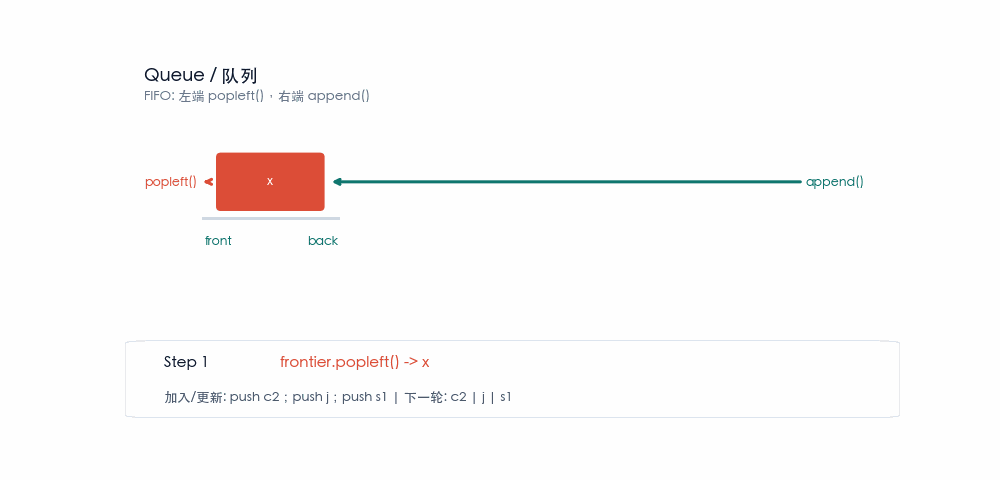

In [14]:
animate_search_frontier('bfs')

In [15]:
path_bfs = run_all()['bfs']['path']

In [16]:
print('path:', '->'.join(path_bfs), ' cost:', path_cost(path_bfs, adj))

path: x->s1->c1  cost: 8


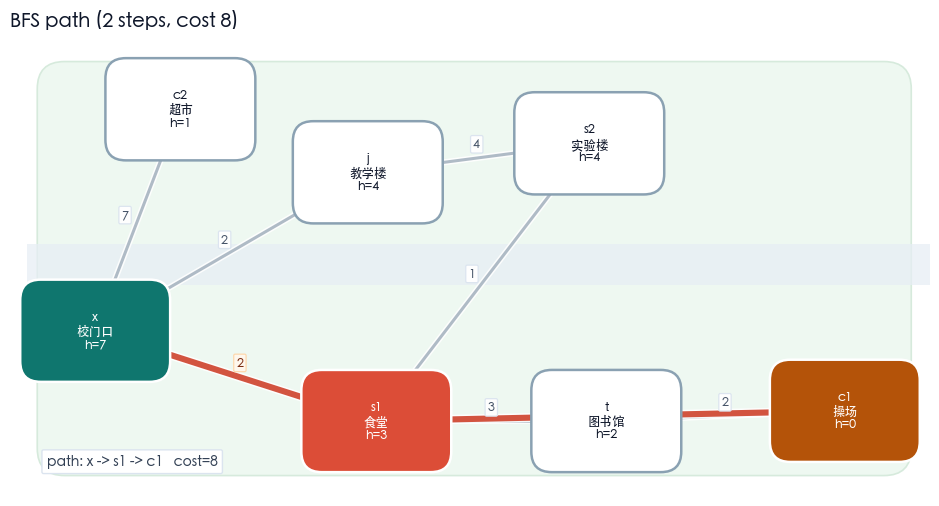

In [17]:
plot_campus(path_bfs, title='BFS path (2 steps, cost 8)')

**思考** · BFS 2 步但代价 8 不是最低——为什么？

<details class="ai-self-check"><summary>查看答案</summary><p>BFS 优化边数，不优化边权之和。</p></details>

## 5. 深度优先 DFS

### 5.1 栈与回溯

LIFO 栈：最后放进去的节点最先被取出，入栈顺序会直接改变搜索路径。

**DFS**

```text
stack = ['x']
u = stack.pop()
stack.append(v)  # v becomes the new top
```

In [18]:
display(operation_trace('dfs'))

,步,算法,取出动作,取出节点,frontier 取出前,frontier 取出后,新加入 / 更新,下一轮 frontier,visited,到达?
0,1,DFS,stack.pop(),x,x,∅,push s1；push j；push c2,s1 | j | c2,x,False
1,2,DFS,stack.pop(),c2,s1 | j | c2,s1 | j,—,s1 | j,x→c2,False
2,3,DFS,stack.pop(),j,s1 | j,s1,push s2,s1 | s2,x→c2→j,False
3,4,DFS,stack.pop(),s2,s1 | s2,s1,—,s1,x→c2→j→s2,False
4,5,DFS,stack.pop(),s1,s1,∅,push t；push c1,t | c1,x→c2→j→s2→s1,False
5,6,DFS,stack.pop(),c1,t | c1,t,—,t,x→c2→j→s2→s1→c1,True


DFS: Stack / 栈 frontier 动画



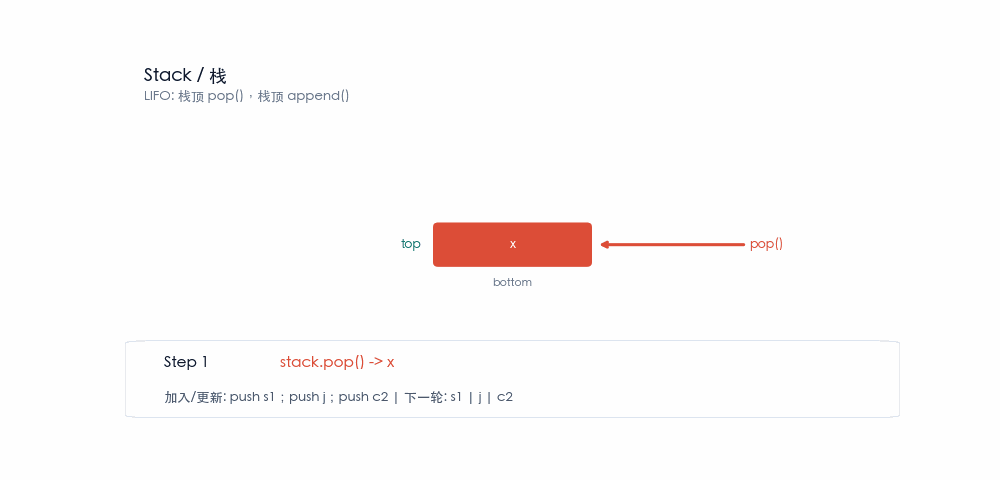

In [19]:
animate_search_frontier('dfs')

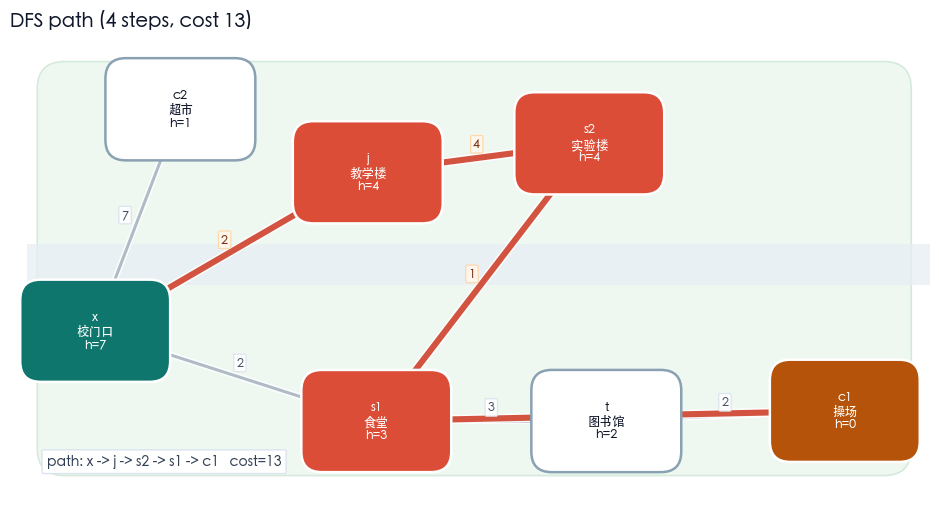

In [20]:
plot_campus(run_all()['dfs']['path'], title='DFS path (4 steps, cost 13)')

**思考** · DFS 路径是否最优？

<details class="ai-self-check"><summary>查看答案</summary><p>否，本例 4 步代价 13，非最低。</p></details>

## 6. 一致代价 UCS

优先队列按 **g(n)** 累计代价排序。本例最优 x→s1→t→c1，代价 7。

**UCS**

```text
frontier.push(node, priority=g[node])
u = frontier.pop_min()
```

In [21]:
display(operation_trace('ucs'))

,步,算法,取出动作,取出节点,frontier 取出前,frontier 取出后,新加入 / 更新,下一轮 frontier,visited,到达?
0,1,UCS,pop_min(g),x,x g=0,∅,push c2；push j；push s1,j g=2 | s1 g=2 | c2 g=7,x,False
1,2,UCS,pop_min(g),j,j g=2 | s1 g=2 | c2 g=7,s1 g=2 | c2 g=7,push s2,s1 g=2 | s2 g=6 | c2 g=7,x→j,False
2,3,UCS,pop_min(g),s1,s1 g=2 | s2 g=6 | c2 g=7,s2 g=6 | c2 g=7,push c1；update s2；push t,s2 g=3 | t g=5 | c2 g=7 | c1 g=8,x→j→s1,False
3,4,UCS,pop_min(g),s2,s2 g=3 | t g=5 | c2 g=7 | c1 g=8,t g=5 | c2 g=7 | c1 g=8,—,t g=5 | c2 g=7 | c1 g=8,x→j→s1→s2,False
4,5,UCS,pop_min(g),t,t g=5 | c2 g=7 | c1 g=8,c2 g=7 | c1 g=8,update c1,c1 g=7 | c2 g=7,x→j→s1→s2→t,False
5,6,UCS,pop_min(g),c1,c1 g=7 | c2 g=7,c2 g=7,—,c2 g=7,x→j→s1→s2→t→c1,True


UCS: Priority queue / 优先队列 frontier 动画



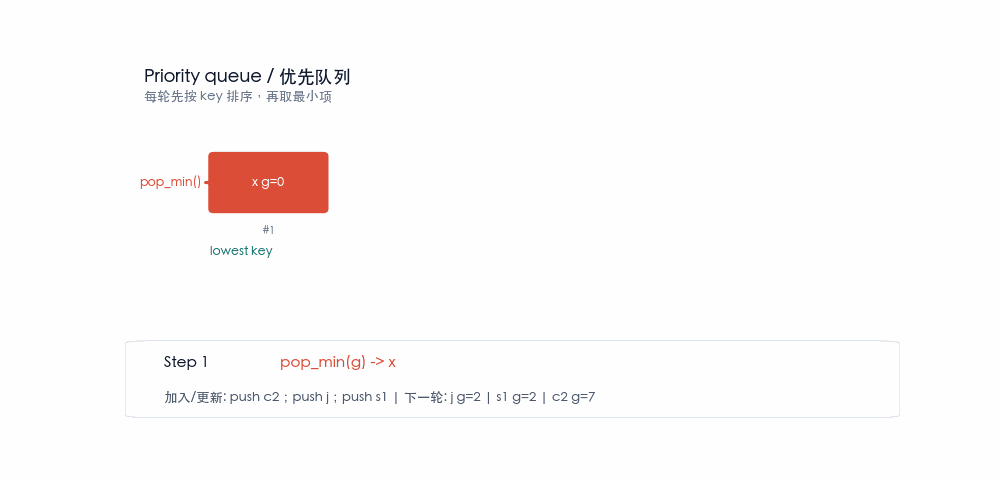

In [22]:
animate_search_frontier('ucs')

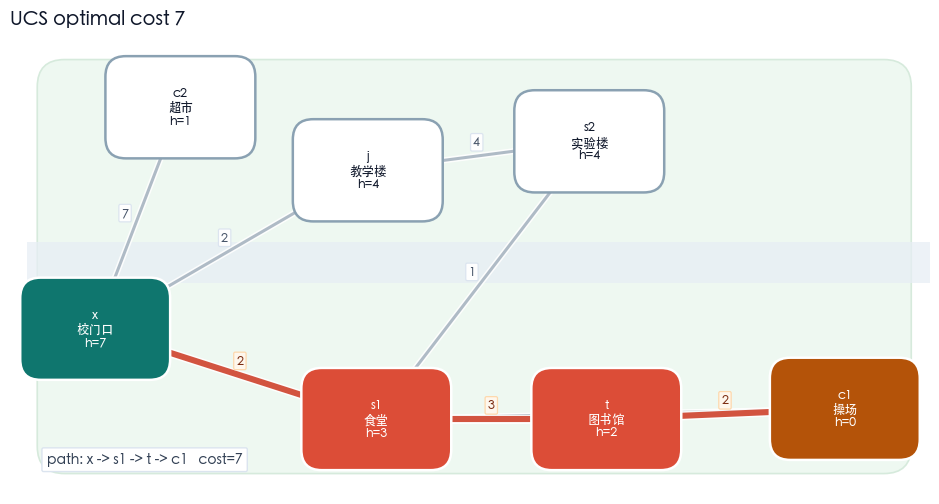

In [23]:
plot_campus(run_all()['ucs']['path'], title='UCS optimal cost 7')

**思考** · UCS 与 BFS 路径差异？

<details class="ai-self-check"><summary>查看答案</summary><p>UCS 代价 7 更优；BFS 步数更少但代价 8。</p></details>

## 7. Greedy 与 A*

Greedy 按 h；A* 按 f=g+h。从 x：c2 的 f=8，s1 的 f=5，故先展开 s1。

In [24]:
display(first_step_scores())

,邻居,g,h,f=g+h,名称
2,s1,2,3,5,食堂
1,j,2,4,6,教学楼
0,c2,7,1,8,超市


### 7.1 Greedy：只看离目标的估计距离 h

它像“看起来最近就先走哪里”，速度直观，但不保证总代价最低。

In [25]:
display(operation_trace('greedy'))

,步,算法,取出动作,取出节点,frontier 取出前,frontier 取出后,新加入 / 更新,下一轮 frontier,visited,到达?
0,1,Greedy,pop_min(h),x,x h=7,∅,push c2；push j；push s1,c2 h=1 | s1 h=3 | j h=4,x,False
1,2,Greedy,pop_min(h),c2,c2 h=1 | s1 h=3 | j h=4,s1 h=3 | j h=4,—,s1 h=3 | j h=4,x→c2,False
2,3,Greedy,pop_min(h),s1,s1 h=3 | j h=4,j h=4,push c1；push s2；push t,c1 h=0 | t h=2 | j h=4 | s2 h=4,x→c2→s1,False
3,4,Greedy,pop_min(h),c1,c1 h=0 | t h=2 | j h=4 | s2 h=4,t h=2 | j h=4 | s2 h=4,—,t h=2 | j h=4 | s2 h=4,x→c2→s1→c1,True


Greedy: Priority queue / 优先队列 frontier 动画



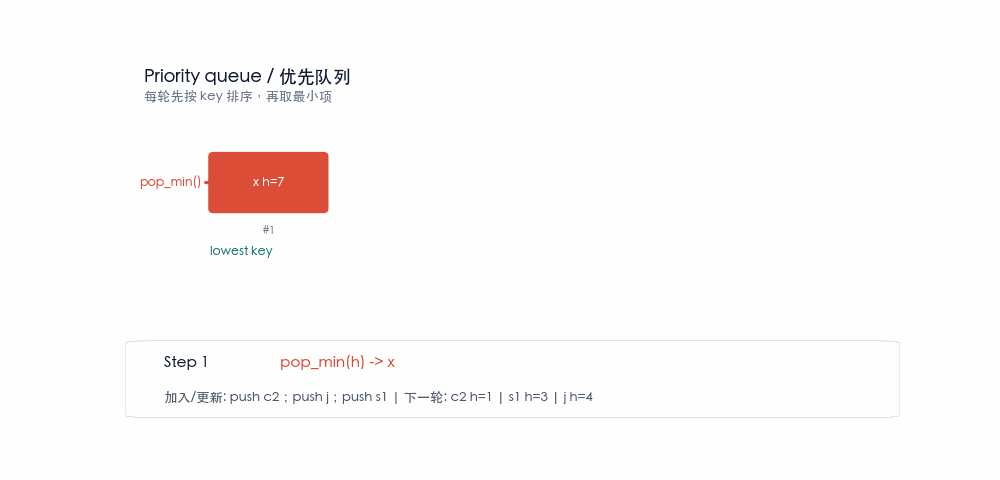

In [26]:
animate_search_frontier('greedy')

### 7.2 A*：同时看已走代价 g 和剩余估计 h

A* 用 f=g+h 排序，把“已经花了多少”和“还可能剩多少”放在同一张账上。

In [27]:
display(operation_trace('astar'))

,步,算法,取出动作,取出节点,frontier 取出前,frontier 取出后,新加入 / 更新,下一轮 frontier,visited,到达?
0,1,A*,pop_min(f),x,x f=7,∅,push c2；push j；push s1,s1 f=5 | j f=6 | c2 f=8,x,False
1,2,A*,pop_min(f),s1,s1 f=5 | j f=6 | c2 f=8,j f=6 | c2 f=8,push c1；push s2；push t,j f=6 | t f=7 | s2 f=7 | c1 f=8 | c2 f=8,x→s1,False
2,3,A*,pop_min(f),j,j f=6 | t f=7 | s2 f=7 | c1 f=8 | c2 f=8,t f=7 | s2 f=7 | c1 f=8 | c2 f=8,—,t f=7 | s2 f=7 | c1 f=8 | c2 f=8,x→s1→j,False
3,4,A*,pop_min(f),t,t f=7 | s2 f=7 | c1 f=8 | c2 f=8,s2 f=7 | c1 f=8 | c2 f=8,update c1,c1 f=7 | s2 f=7 | c2 f=8,x→s1→j→t,False
4,5,A*,pop_min(f),c1,c1 f=7 | s2 f=7 | c2 f=8,s2 f=7 | c2 f=8,—,s2 f=7 | c2 f=8,x→s1→j→t→c1,True


A*: Priority queue / 优先队列 frontier 动画



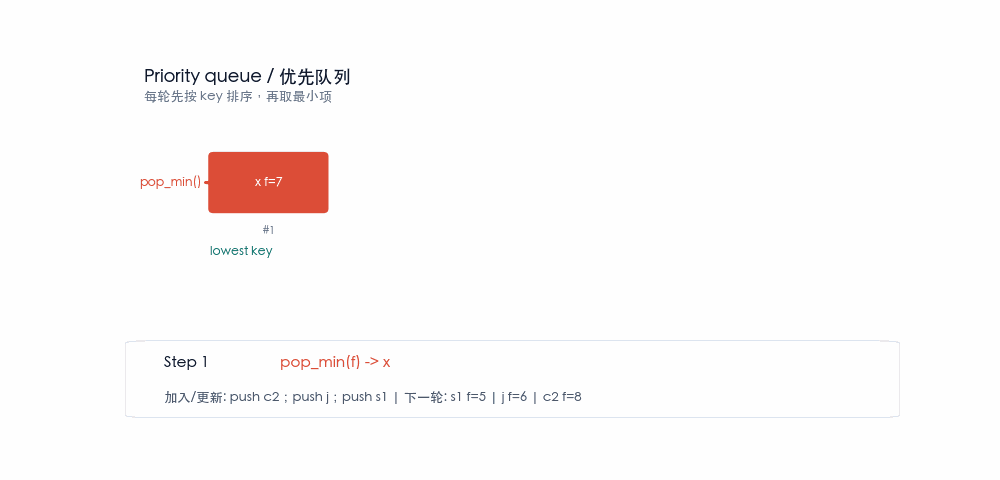

In [28]:
animate_search_frontier('astar')

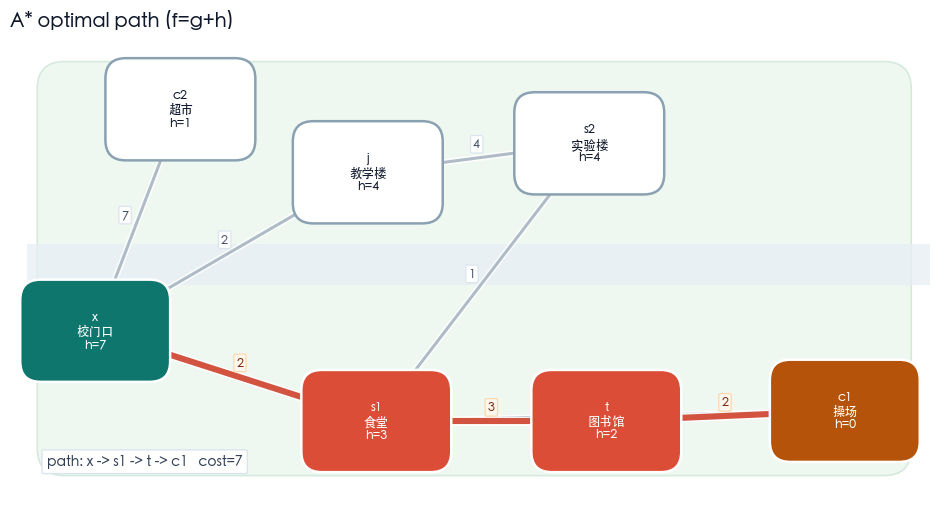

In [29]:
plot_campus(run_all()['astar']['path'], title='A* optimal path (f=g+h)')

**思考** · A* 在本图是否最优？

<details class="ai-self-check"><summary>查看答案</summary><p>是，与 UCS 同路径代价 7。</p></details>

## 8. 五种算法对照

In [30]:
display(comparison_table())

,算法,路径,步数,代价,与网页
0,DFS,x→j→s2→s1→c1,4,13,✓
1,BFS,x→s1→c1,2,8,✓
2,UCS,x→s1→t→c1,3,7,✓
3,Greedy,x→s1→c1,2,8,✓
4,A*,x→s1→t→c1,3,7,✓


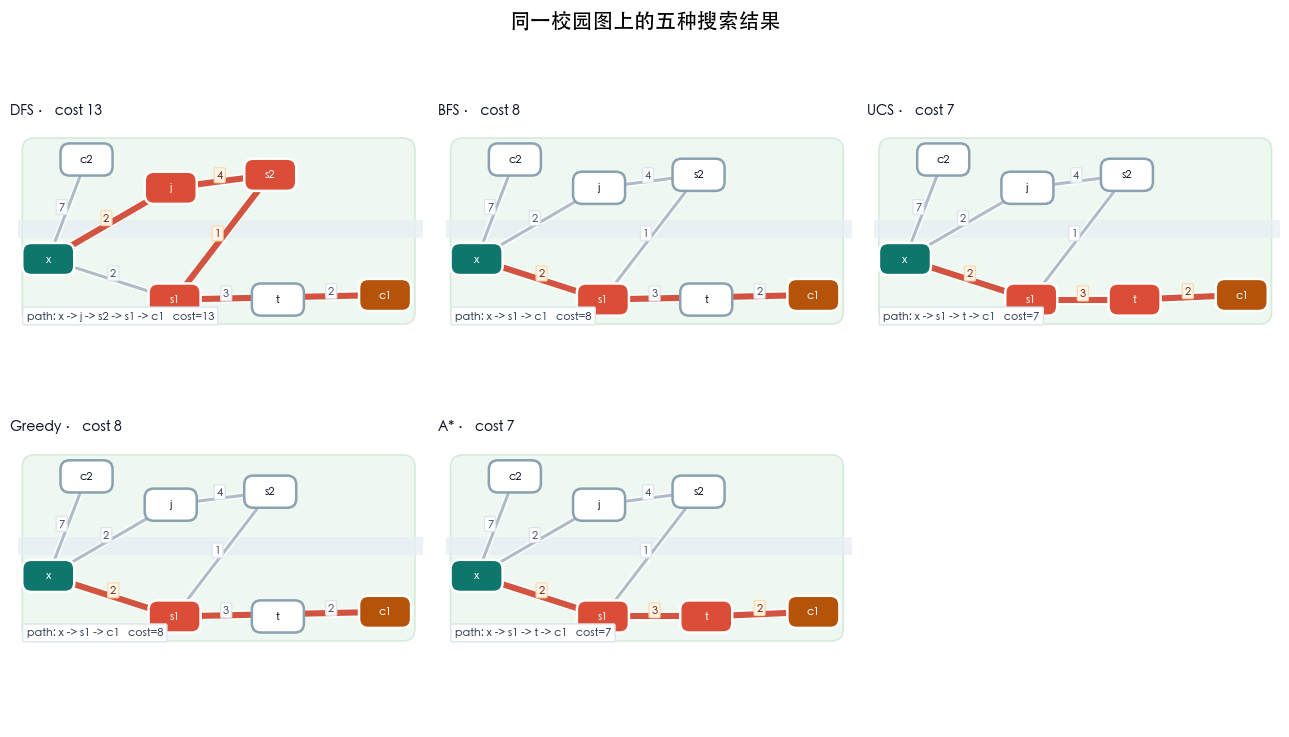

In [31]:
plot_all_paths()

In [32]:
verify_against_web()

✓ 五种算法路径与 ch5.html 完全一致


## 小结

BFS 队列保证最少步数；DFS 栈不保证最优；UCS/A* 在加权图上求最低代价。

对照 [ch5.html](../ch5.html) 步进动画验证每一步预测。

## 练习

1. 若所有边权为 1，BFS 与 UCS 路径是否相同？
2. 改变 DFS 入栈顺序，路径如何变化？